In [1]:
import math
import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from tqdm import tqdm
import time

from transformer.transformer import Transformer

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = torch.device('cpu')
print(device)

cuda


# Model

In [13]:
class DecoderOnly(nn.Module):
    def __init__(self, d_model, nhead, num_encoder_layers, num_decoder_layers, ffn_hidden, vocab_size, max_seq_len):
        super(DecoderOnly, self).__init__()

        self.src_embedding = nn.Embedding(vocab_size, d_model)
        self.tgt_embedding = nn.Embedding(vocab_size, d_model)
        self.positional_embeddings = nn.Embedding(max_seq_len, d_model)

        self.transformer = Transformer(d_model, nhead, num_encoder_layers, num_decoder_layers, ffn_hidden, dropout=None)
        self.linear = nn.Linear(d_model, vocab_size)

    def forward(self, src, use_mask=True):
        src_positions = torch.arange(src.size(1)).unsqueeze(0).expand(src.size(0), -1).to(src.device)
        src = self.src_embedding(src) + self.positional_embeddings(src_positions)

        mask = self.transformer.generate_square_subsequent_mask(src.size(1)).to(src.device)
        output = self.transformer(src, tgt_mask=mask)
        
        output = self.linear(output)

        return output

In [14]:
vocab_size = 26 + 1  # add the <s>=26 token
d_model = 16
ffn_hidden = d_model * 4
nhead = 2
num_encoder_layers = 0
num_decoder_layers = 1

model = DecoderOnly(
    d_model=d_model,
    nhead=nhead,
    num_encoder_layers=num_encoder_layers,
    num_decoder_layers=num_decoder_layers,
    ffn_hidden=ffn_hidden,
    vocab_size=vocab_size,
    max_seq_len=1024 * 4
).to(device)

# Inference

In [15]:
def decode_only_batch(model, b=2, n=8, avg=8):
    model.eval()
    device = next(model.parameters()).device

    times = []
    tgt = torch.tensor([[26]] * b, dtype=torch.long).to(device)  # shape (b, 1)

    with torch.no_grad():
        for _ in range(n):
            # Run forward pass avg times and average the time
            step_times = []
            for _ in range(avg):
                torch.cuda.synchronize()
                start_time = time.time()

                logits = model(tgt).squeeze(0)  # shape (b, s, v)

                torch.cuda.synchronize()
                end_time = time.time()
                step_times.append(end_time - start_time)
            
            times.append(sum(step_times) / avg)

            predicted_index = torch.argmax(logits, dim=-1)[:, -1]  # shape (b,)
            tgt = torch.cat((tgt, predicted_index.unsqueeze(1)), dim=1)  # shape (b, s+1)

    output_strs = []
    for i in range(tgt.size(0)):
        output_str = ''.join([chr(token + ord('a')) if token != 26 else 'a' for token in tgt[i].cpu().numpy()])[1:]
        output_strs.append(output_str)

    return output_strs, times

In [20]:
# decode batch size b sequences starting with <s> token
output_strs, times = decode_only_batch(model, b=2, n=8)

for i, output_str in enumerate(output_strs):
    print(f"Output[{i}]: {output_str}")

print(times)

Output[0]: jrrrrsrr
Output[1]: jrrrrsrr
[0.0019688010215759277, 0.0021649301052093506, 0.003577977418899536, 0.0026580393314361572, 0.01193016767501831, 0.011200189590454102, 0.011845946311950684, 0.0032751858234405518]


100%|██████████| 64/64 [00:15<00:00,  4.01it/s]


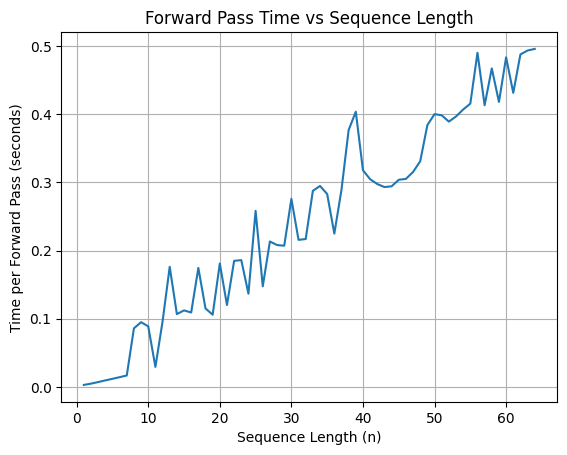

In [21]:
import time
import matplotlib.pyplot as plt

seq_len = int(64)
n_values = list(range(1, seq_len + 1))

plot_times = []
for n in tqdm(n_values):
    torch.cuda.synchronize()
    start_time = time.time()
    
    _, _ = decode_only_batch(model, b=2, n=n, avg=1)

    torch.cuda.synchronize()
    total_time = time.time() - start_time
    
    plot_times.append(total_time)

plt.plot(n_values, plot_times)
plt.xlabel('Sequence Length (n)')
plt.ylabel('Time per Forward Pass (seconds)')
plt.title('Forward Pass Time vs Sequence Length')
plt.grid()
plt.show()